In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(Path.home() / "project/crc-pm/code"))
import src


In [2]:
DATA_DIR = Path.home() / "project/crc-pm/result/dr-anno" / "ready_for_anno.h5ad"
adata = sc.read_h5ad(str(DATA_DIR))

In [3]:
# use different res
leiden_res = [0.25, 0.5, 1.0]
for i in leiden_res:
    sc.tl.leiden(adata, key_added=f"leiden_res{i}", resolution=i, flavor="igraph", n_iterations=2)

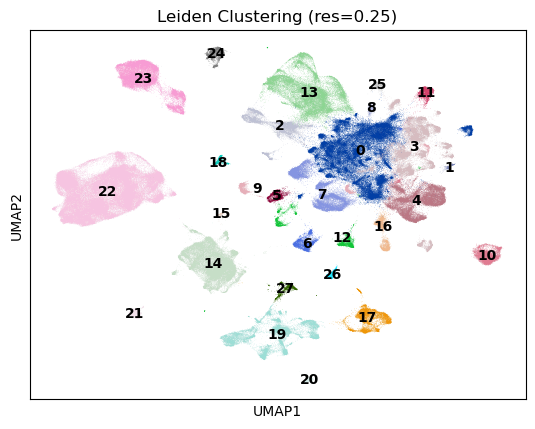

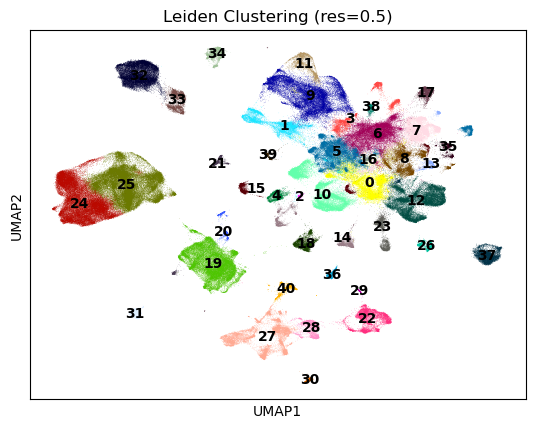

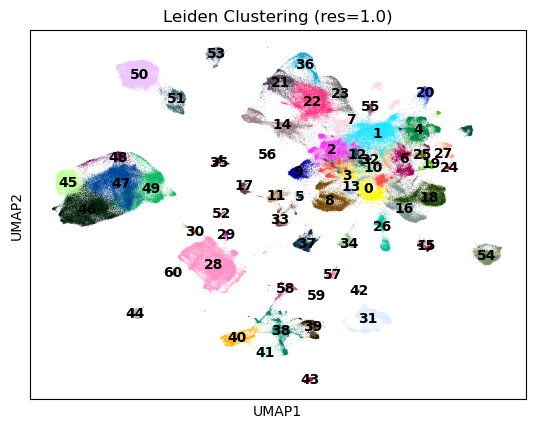

In [4]:
for i in leiden_res:
    sc.pl.umap(
        adata,
        color=f"leiden_res{i}",
        legend_loc="on data",
        title=f"Leiden Clustering (res={i})",
    )

In [5]:
adata.obs.columns

Index(['Patient', 'Tissue', 'Sample', 'OrigCellType', 'Study', 'CellID',
       'Glob_Sample', 'Glob_Patient', 'Glob_CellID', 'OrigCellTypeFull',
       'Batch', 'Assay', 'Protocol', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_20_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier',
       'qc_outlier', 'scANVI_CellType', 'scANVI_CellType_uncertainty',
       'Study_Batch', 'leiden_res0.25', 'leiden_res0.5', 'leiden_res1.0'],
      dtype='object')

In [6]:
coarse_label_dict = {
    'Unknown' : 'Unknown',
    'Cancer TA-like' : 'Tumour',
    'Cancer Colonocyte-like' : 'Tumour',
    'Cancer Goblet-like' : 'Tumour',
    'Cancer Crypt-like' : 'Tumour',
    'Cancer BEST4' : 'Tumour',
    'Macrophage': 'Myeloid' ,
    'Monocyte classical': 'Mono' ,
    'Tuft': 'Epithelium',
    'TA progenitor': 'Epithelium',
    'Enteroendocrine': 'Epithelium',
    'Colonocyte': 'Epithelium',
    'Mast cell': 'Mast',
    'Endothelial venous': 'Endothelium', 
    'Endothelial arterial': 'Endothelium', 
    'Monocyte non-classical': 'Mono' , 
    'Plasma IgA': 'Plasma', 
    'Goblet': 'Epithelium', 
    'cDC2': 'DC', 
    'T cell CD8': 'T/NK/ILC', 
    'T cell regulatory': 'T/NK/ILC', 
    'B cell memory': 'B', 
    'cDC1': 'DC', 
    'DC3': 'DC', 
    'Fibroblast S3': 'Stromal',
    'DC mature': 'DC', 
    'Pericyte': 'Stromal', 
    'Fibroblast S1': 'Stromal', 
    'Fibroblast S2': 'Stromal', 
    'GC B cell': 'GC B', 
    'T cell CD4': 'T/NK/ILC', 
    'Plasma IgG': 'Plasma', 
    'B cell naive': 'B', 
    'ILC':'T/NK/ILC', 
    'pDC': 'DC', 
    'Plasma IgM': 'Plasma', 
    'Cancer cell circulating': 'Tumour', 
    'NK cell': 'T/NK/ILC', 
    'Schwann cell': 'Stromal', 
    'Eosinophil': 'Myeloid', 
    'Endothelial lymphatic':'Endothelium', 
    'Neutrophil': 'Myeloid', 
    'T cell gd': 'T/NK/ILC', 
    'Plasmablast': 'Plasma', 
    'Colonocyte BEST4': 'Epithelium', 
    'Crypt cell': 'Epithelium', 
    'T cell CD4 naive': 'T/NK/ILC', 
    'T cell CD8 naive': 'T/NK/ILC',
}
coarse = [coarse_label_dict[_] for _ in adata.obs['scANVI_CellType']]
adata.obs['scANVI_CellType_coarse'] = coarse


/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


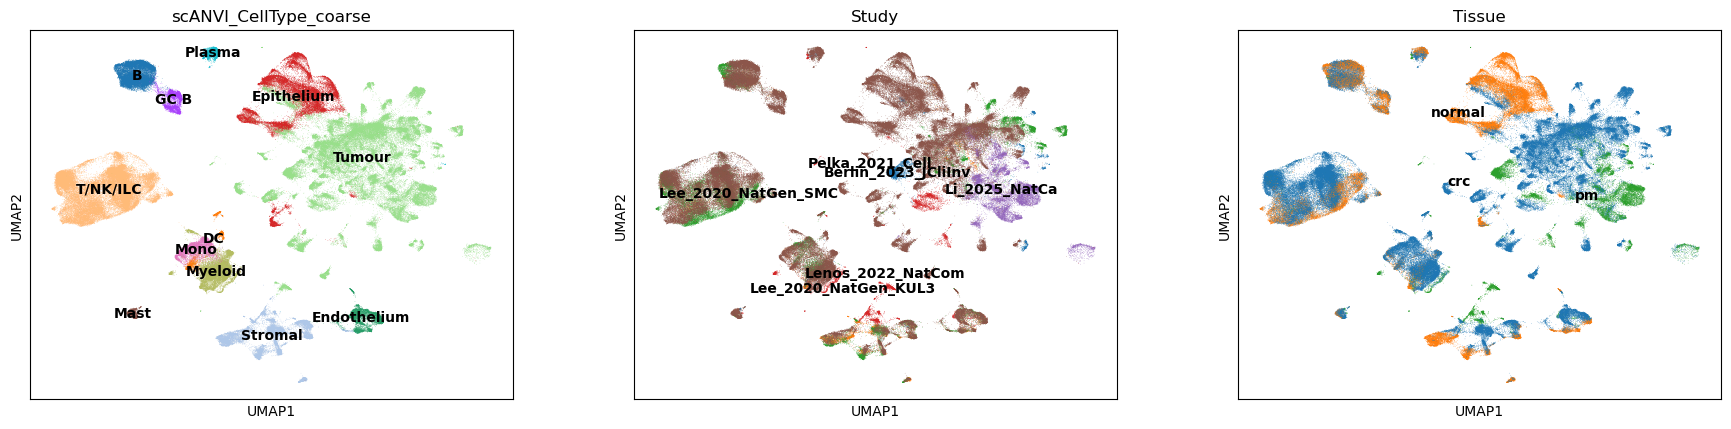

In [7]:
sc.pl.umap(adata[adata.obs['scANVI_CellType_coarse'] != 'Unknown' ],
    color= ["scANVI_CellType_coarse",'Study','Tissue'],
    legend_loc="on data",
)

/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


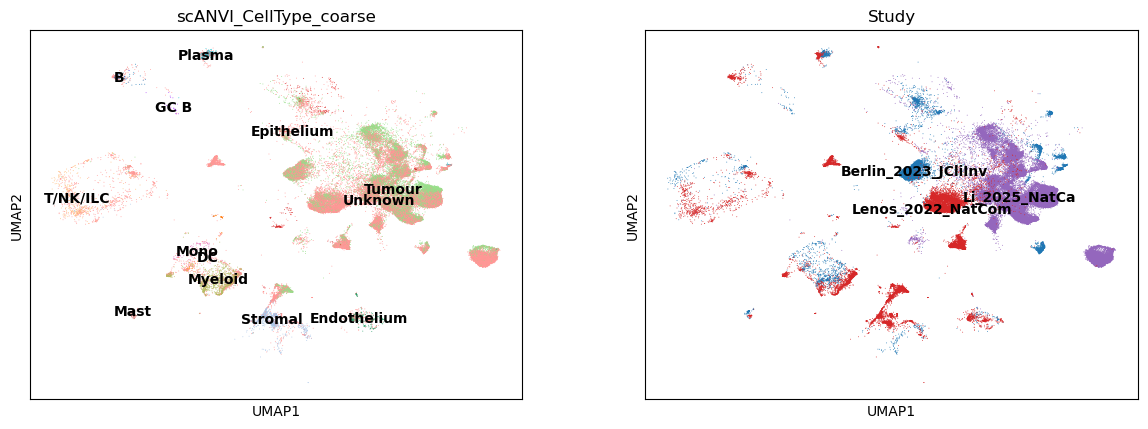

In [8]:
sc.pl.umap(adata[adata.obs['Study'].isin(['Li_2025_NatCa', 'Berlin_2023_JCliInv', 'Lenos_2022_NatCom'])],
    color= ["scANVI_CellType_coarse",'Study'],
    legend_loc="on data",)

In [9]:
### construct cluster-anno relation
annodict_res025 = {
    0: 'Tumor',
    1: 'Tumor',
    2: 'Epithelium',
    3: 'Tumor',
    4: 'Tumor',
    5: 'Tumor',
    6: 'Tumor',
    7: 'Tumor',
    8: 'Tumor',
    9: 'Tumor',
    10: 'Tumor',
    11: 'Tumor',
    12: 'Tumor',
    13: 'Epithelium',
    14: 'Myeloid',
    15: 'Tumor',
    16: 'Tumor',
    17: 'Endothelium',
    18: 'Tumor',
    19: 'Stromal',
    20: 'Stromal',
    21: 'Mast',
    22: 'T/NK/ILC',
    23: 'B',
    24: 'Plasma',
    25: 'Tumor',
    26: 'Tumor',
    27: 'Tumor',
}

In [10]:
adata.obs['man_anno_coarse'] = [annodict_res025[int(_)] for _ in adata.obs['leiden_res0.25']]

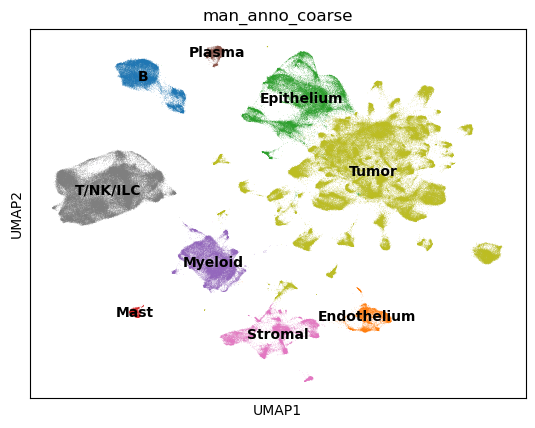

In [11]:
sc.pl.umap(adata,
    color= ['man_anno_coarse'],
    legend_loc="on data",
)

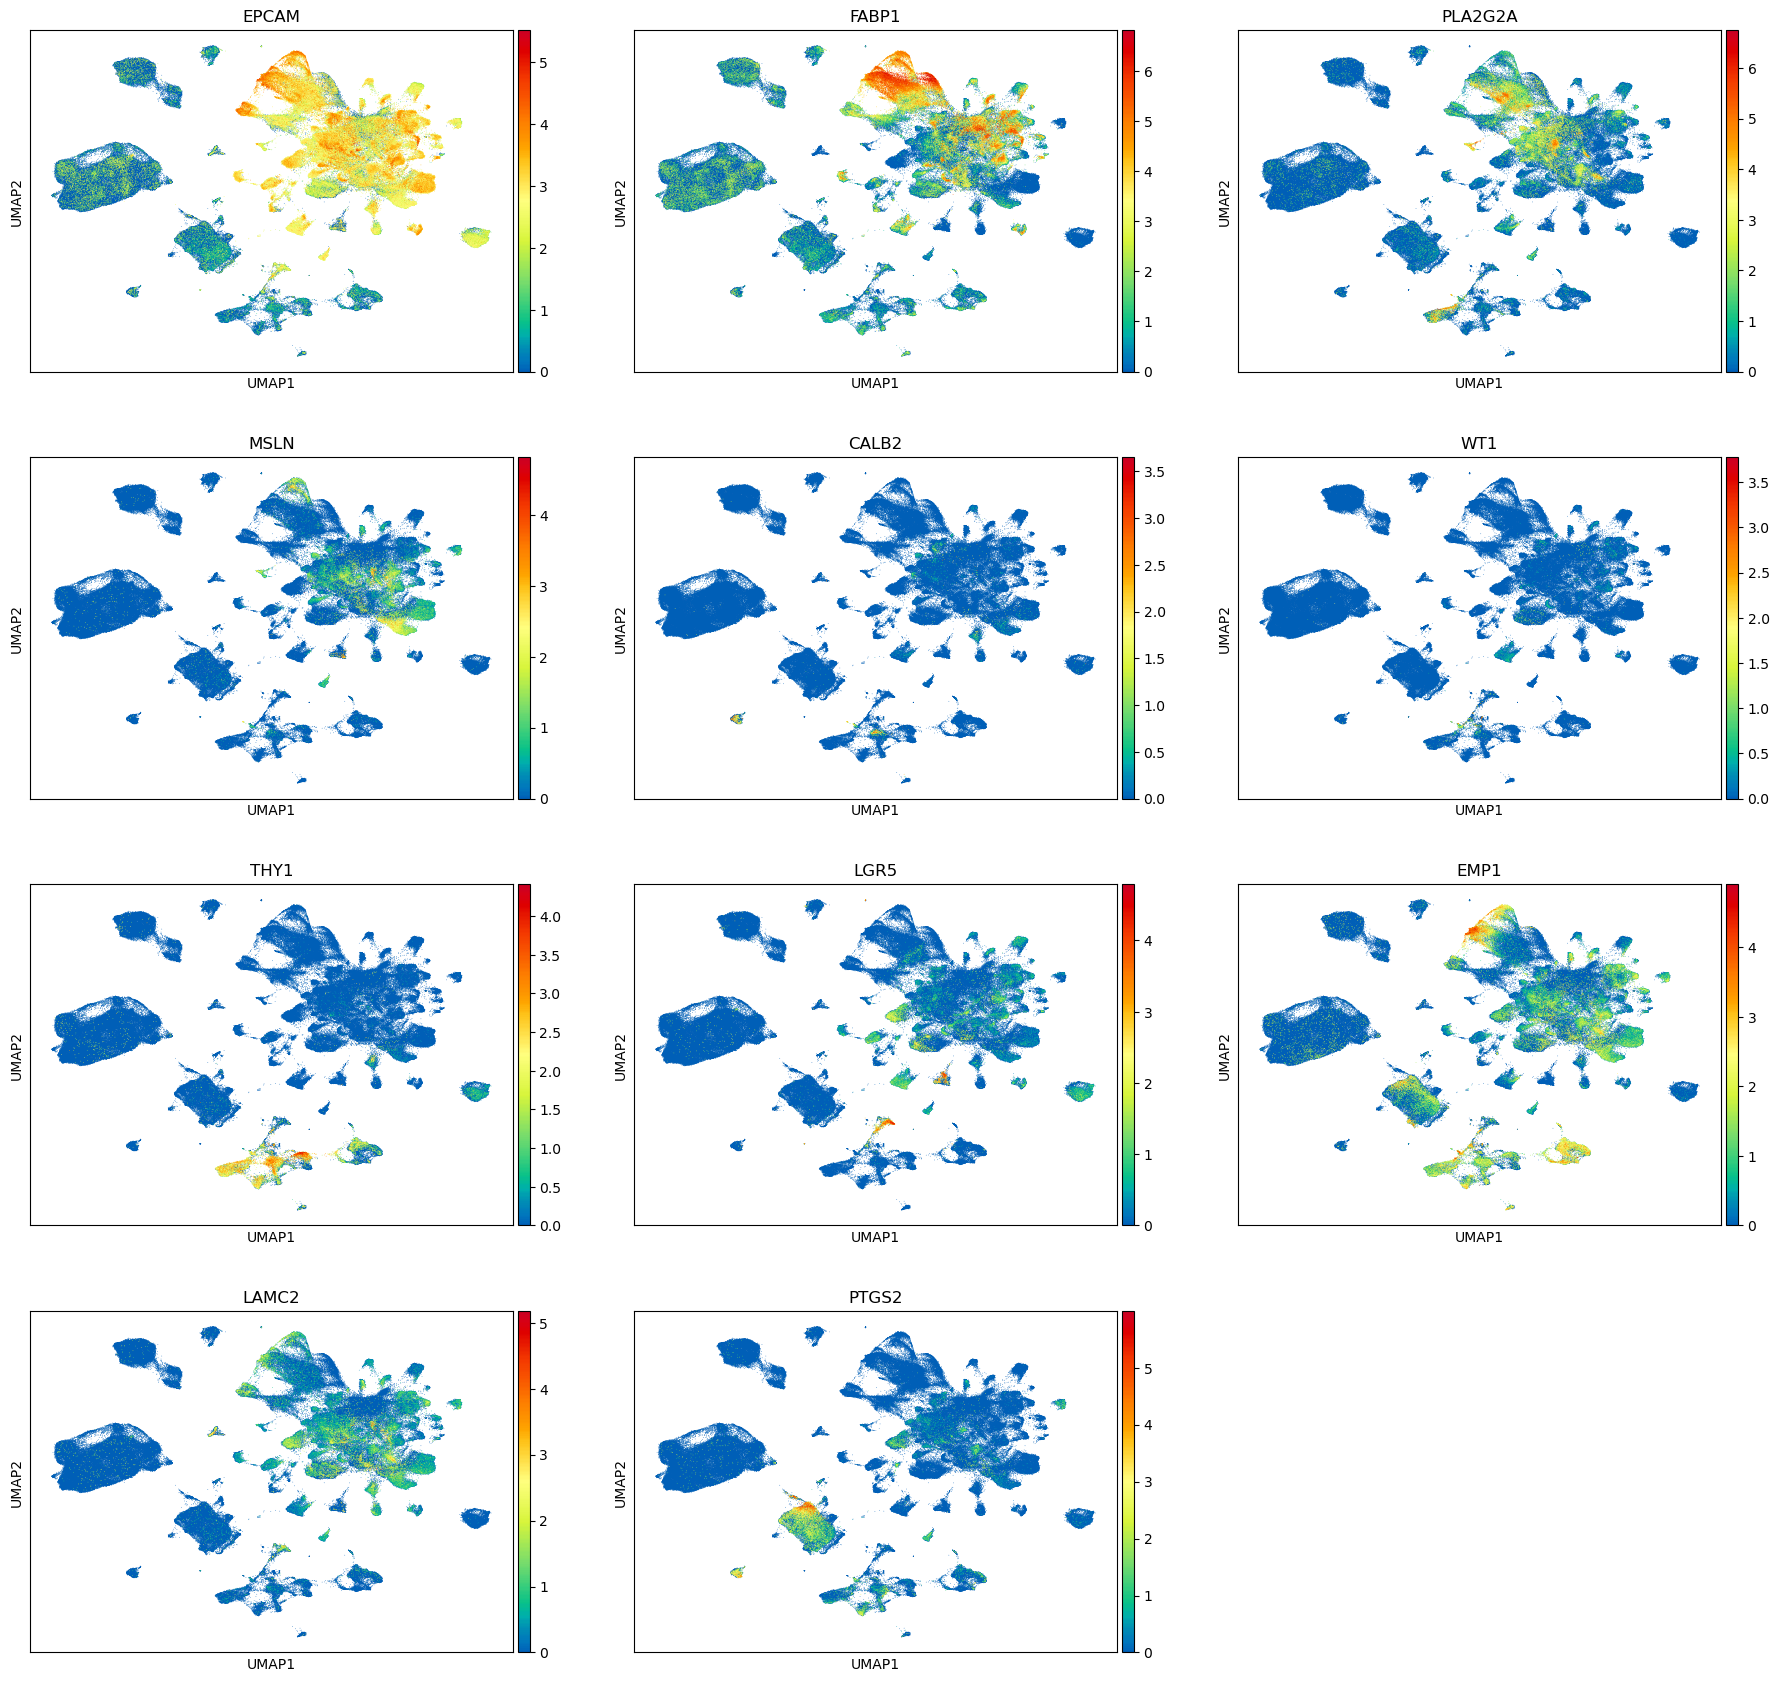

In [12]:
cmap = src.GenCmap.saturated()
sc.pl.umap(
    adata,
    color = [
        "EPCAM", "FABP1", "PLA2G2A", # Epithelium
        'MSLN','CALB2', 'WT1', 'THY1', # Mesothelium
        "LGR5", "EMP1", "LAMC2","PTGS2", # Stem, HRC and CAF subtype
        ],
    gene_symbols="gene_name",
    layer="log1p",
    cmap=cmap,
    ncols=3,
    size=1,
)

In [13]:
compartment_dict = {
    'T/NK/ILC':'Immune',
    'B':'Immune',
    'Mast':'Immune',
    'Myeloid':'Immune',
    'Plasma':'Immune',
    'Stromal':'Stromal',
    'Endothelium':'Stromal',
    'Mast':'Immune',
    'Tumor':'Epithelium',
    'Epithelium':'Epithelium',
}
adata.obs["Compartment"] = adata.obs["man_anno_coarse"].map(compartment_dict)

In [14]:
OUTDIR = Path.home()/'project/crc-pm/result/latest.h5ad'
adata.write_h5ad(OUTDIR)